# Notebook C (esquema combinado/ingenuo) — Análisis ignorando la explotación
### Tuberculosis bovina · CV por animal, sin la granja en ningún punto

Este cuaderno implementa el enfoque **más sencillo y más común por defecto**: se **ignora la
explotación por completo** —ni como variable de agrupamiento en la validación, ni como
covariable del modelo— y se realiza **validación cruzada estándar a nivel de animal** con
ajuste de modelos sobre las covariables del hospedador.

> **Por qué es importante mostrarlo.** Es el *pipeline* que correría cualquiera que vuelque los
> datos en `scikit-learn` sin considerar la estructura de agrupamiento. Sirve como **línea base
> ingenua** y como advertencia: este esquema (a) **no generaliza honestamente** a granjas nuevas
> (como sí estima el *leave-one-farm-out*) y (b) **oculta** la estructura de granja que los otros
> análisis revelan. Es propenso al optimismo por compartir granjas entre *train* y *test*, pero
> precisamente por eso, si **aun así** no encuentra señal, el resultado negativo es más robusto.
>
> Este cuaderno cierra un **tríptico de esquemas de validación**:
> 1. *Leave-one-farm-out* (agrupar por granja) → predicción en **granja nueva**.
> 2. CV-animal con la granja como covariable → predicción en **granja conocida**.
> 3. **CV-animal ignorando la granja (este cuaderno)** → *pooling* ingenuo.


## 1. Setup, carga y limpieza

In [1]:
# !pip install -q scikit-learn xgboost shap statsmodels matplotlib seaborn
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import tb_utils as tb
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.model_selection import RepeatedStratifiedKFold, RepeatedKFold
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
                             matthews_corrcoef, recall_score)
from scipy.stats import spearmanr, chi2
import xgboost as xgb
PALETTE = tb.set_plot_style(); tb.set_seeds(tb.SEED)
import os
DATA = next((p for p in ["BD.csv","/mnt/project/BD.csv","data/BD.csv"] if os.path.exists(p)), "BD.csv")
df = tb.clean(tb.load_raw(DATA))
print("Datos:", df.shape)

# Conjunto de variables: SOLO biomarcadores/host. La explotación NO se usa en ningún punto.
FEAT = tb.MODEL_FEATURES                  # incluye continuas, serología y RAZA2 (no Expl)
NUM  = tb.NUM_FEATURES; CAT = ["RAZA2"]
print("Variables del modelo (sin granja):", FEAT)

Datos: (106, 19)
Variables del modelo (sin granja): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'EDAD', 'PIROPLASMA', 'THEILERIA', 'ANAPLASMA', 'RAZA2']


## 2. Modelos y validación cruzada a nivel de animal (5×10)

In [2]:
def make_pipe(estimator):
    return Pipeline([("prep", tb.make_preprocessor(numeric=NUM, categorical=CAT)), ("clf", estimator)])
def logit(C=0.3):
    return LogisticRegression(penalty="l2", C=C, class_weight="balanced", solver="liblinear",
                              max_iter=4000, random_state=tb.SEED)
def xgbc():
    return xgb.XGBClassifier(n_estimators=150, max_depth=2, learning_rate=0.05, subsample=0.8,
                             colsample_bytree=0.8, reg_lambda=3.0, min_child_weight=3,
                             eval_metric="logloss", random_state=tb.SEED)

def cv_classify(target, models, n_splits=5, n_repeats=10):
    d = tb.target_subset(df, target); y = d[target].astype(int).values; X = d[FEAT]
    cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=tb.SEED)
    rows=[]
    for name,est in models.items():
        pr,roc,br,mcc,se,sp=[],[],[],[],[],[]
        for tr,te in cv.split(X,y):
            pipe=make_pipe(est); pipe.fit(X.iloc[tr],y[tr]); p=pipe.predict_proba(X.iloc[te])[:,1]
            pr.append(average_precision_score(y[te],p)); roc.append(roc_auc_score(y[te],p))
            br.append(brier_score_loss(y[te],p)); mcc.append(matthews_corrcoef(y[te],(p>=.5).astype(int)))
            se.append(recall_score(y[te],(p>=.5).astype(int),pos_label=1,zero_division=0))
            sp.append(recall_score(y[te],(p>=.5).astype(int),pos_label=0,zero_division=0))
        rows.append(dict(modelo=name, PR_AUC=np.mean(pr), PR_sd=np.std(pr), ROC=np.mean(roc),
                         Brier=np.mean(br), MCC=np.mean(mcc), Sens=np.mean(se), Spec=np.mean(sp)))
    return pd.DataFrame(rows), y.mean()

res, base = cv_classify("Lesiones_TB", {"LogReg(L2)":logit(), "XGBoost":xgbc()})
print(f"[Lesiones_TB] CV animal 5×10, SIN granja — línea base PR-AUC = {base:.3f}")
print(res.round(3).to_string(index=False))
print("\n→ ROC≈0.46 (≈ azar) y MCC<0: ignorando la granja y con solo biomarcadores no hay señal.")

[Lesiones_TB] CV animal 5×10, SIN granja — línea base PR-AUC = 0.613
    modelo  PR_AUC  PR_sd   ROC  Brier    MCC  Sens  Spec
LogReg(L2)   0.634  0.076 0.456  0.283 -0.080 0.511 0.407
   XGBoost   0.720  0.061 0.543  0.259 -0.026 0.708 0.268

→ ROC≈0.46 (≈ azar) y MCC<0: ignorando la granja y con solo biomarcadores no hay señal.


In [3]:
# Los otros tres desenlaces
def cv_regress(target):
    d=tb.target_subset(df,target); y=d[target].values.astype(float); X=d[FEAT]
    cv=RepeatedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)
    sp,mae=[],[]
    for tr,te in cv.split(X):
        pipe=make_pipe(PoissonRegressor(alpha=1.0,max_iter=5000)); pipe.fit(X.iloc[tr],y[tr])
        p=pipe.predict(X.iloc[te])
        if len(np.unique(y[te]))>1: sp.append(spearmanr(y[te],p).correlation)
        mae.append(np.mean(np.abs(y[te]-p)))
    return np.nanmean(sp), np.mean(mae)

resp,_=cv_classify("Patron_lesiones", {"LogReg(L2)":logit()})
print("[Patron_lesiones] (n=65):", resp[["modelo","PR_AUC","ROC","MCC"]].round(3).to_dict("records")[0])
for t in ["IDTC","Score_lesional"]:
    s,m=cv_regress(t); print(f"[{t}] Spearman fuera de muestra={s:+.3f}  MAE={m:.2f}")

[Patron_lesiones] (n=65): {'modelo': 'LogReg(L2)', 'PR_AUC': 0.485, 'ROC': 0.511, 'MCC': 0.043}


[IDTC] Spearman fuera de muestra=+0.136  MAE=4.77


[Score_lesional] Spearman fuera de muestra=-0.001  MAE=1.63


## 3. Calibración

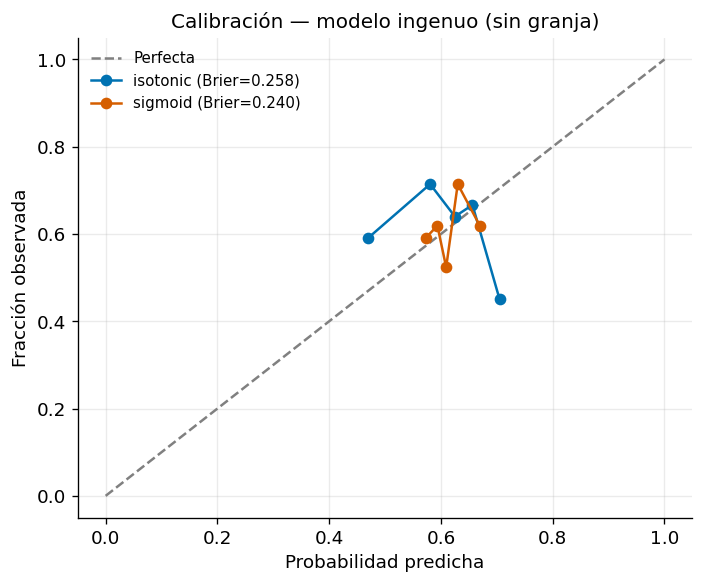

In [4]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict
d=tb.target_subset(df,"Lesiones_TB"); y=d["Lesiones_TB"].astype(int).values
fig,ax=plt.subplots(figsize=(6,5)); ax.plot([0,1],[0,1],"--",color="grey",label="Perfecta")
for method,color in [("isotonic",PALETTE[0]),("sigmoid",PALETTE[1])]:
    cal=CalibratedClassifierCV(make_pipe(logit()), method=method, cv=5)
    p=cross_val_predict(cal, d[FEAT], y, cv=StratifiedKFold(5,shuffle=True,random_state=tb.SEED), method="predict_proba")[:,1]
    f,mp=calibration_curve(y,p,n_bins=5,strategy="quantile")
    ax.plot(mp,f,"o-",color=color,label=f"{method} (Brier={brier_score_loss(y,p):.3f})")
ax.set_xlabel("Probabilidad predicha"); ax.set_ylabel("Fracción observada")
ax.set_title("Calibración — modelo ingenuo (sin granja)"); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig("figures/figC1_calibration.png"); plt.show()

## 4. Interpretabilidad (SHAP / PDP / permutación) — solo biomarcadores

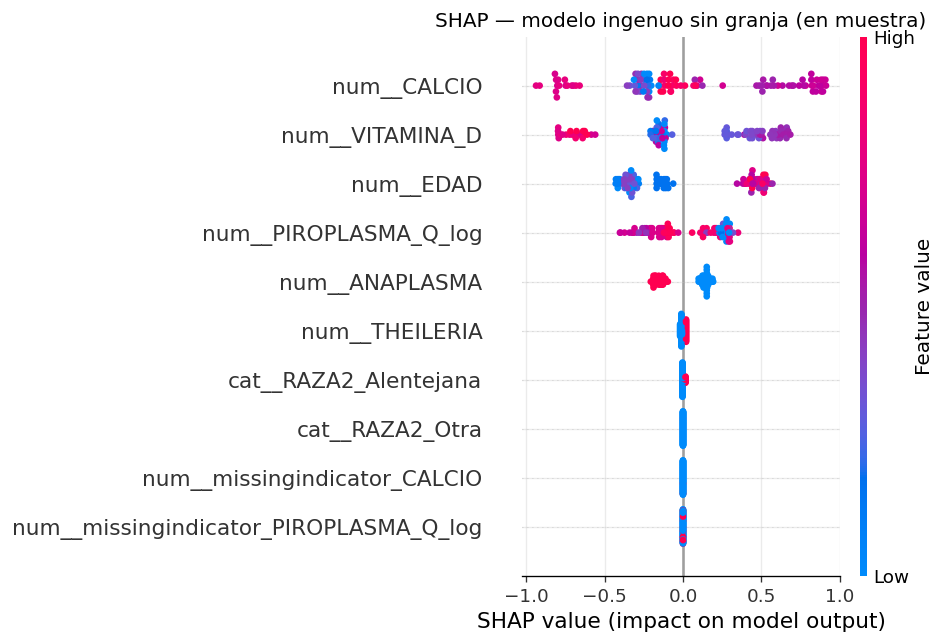

In [5]:
import shap
pipe=make_pipe(xgbc()).fit(d[FEAT], y)
prep=pipe.named_steps["prep"]; clf=pipe.named_steps["clf"]
Xt=prep.transform(d[FEAT]); names=prep.get_feature_names_out()
sv=shap.TreeExplainer(clf).shap_values(Xt)
plt.figure(); shap.summary_plot(sv, Xt, feature_names=names, show=False, max_display=10)
plt.title("SHAP — modelo ingenuo sin granja (en muestra)"); plt.tight_layout()
plt.savefig("figures/figC2_shap_summary.png", bbox_inches="tight"); plt.show()

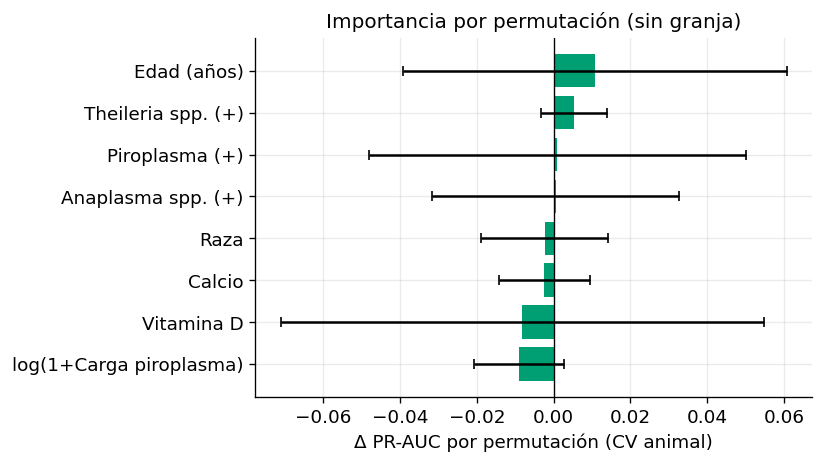

Barras compatibles con 0 → ningún biomarcador aporta señal robusta al ignorar la granja.


In [6]:
# Importancia por permutación (CV animal) con IC entre folds
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold
imp_runs=[]
for tr,te in StratifiedKFold(5,shuffle=True,random_state=tb.SEED).split(d[FEAT],y):
    p=make_pipe(logit()).fit(d[FEAT].iloc[tr],y[tr])
    pi=permutation_importance(p,d[FEAT].iloc[te],y[te],scoring="average_precision",n_repeats=30,random_state=tb.SEED)
    imp_runs.append(pd.Series(pi.importances_mean,index=FEAT))
imp=pd.concat(imp_runs,axis=1); order=imp.mean(axis=1).sort_values().index
fig,ax=plt.subplots(figsize=(7,4))
ax.barh([tb.PRETTY.get(i,i) for i in order], imp.mean(axis=1)[order], xerr=imp.std(axis=1)[order],
        color=PALETTE[2], capsize=3); ax.axvline(0,color="k",lw=.8)
ax.set_xlabel("Δ PR-AUC por permutación (CV animal)"); ax.set_title("Importancia por permutación (sin granja)")
plt.tight_layout(); plt.savefig("figures/figC3_perm_importance.png"); plt.show()
print("Barras compatibles con 0 → ningún biomarcador aporta señal robusta al ignorar la granja.")

## 5. Asociación ingenua vs. ajustada: lo que oculta ignorar la granja

Estimamos la asociación de cada biomarcador con la lesión **sin ajustar** (ingenua) y
**ajustando por explotación**, para evidenciar la confusión por granja. El E-value cuantifica
la fragilidad de la estimación ingenua frente a confusión no medida.


In [7]:
import statsmodels.formula.api as smf
import math
dz=d.copy()
for c in ["VITAMINA_D","CALCIO","EDAD"]: dz[c+"_z"]=(dz[c]-dz[c].mean())/dz[c].std()
rows=[]
for c in ["VITAMINA_D","CALCIO","EDAD"]:
    dd=dz.dropna(subset=[c+"_z"])
    mu=smf.logit(f"Lesiones_TB ~ {c}_z", dd).fit(disp=0)
    ma=smf.logit(f"Lesiones_TB ~ {c}_z + C(Expl)", dd).fit(disp=0)
    oru=np.exp(mu.params[c+"_z"]); ciu=np.exp(mu.conf_int().loc[c+"_z"])
    ora=np.exp(ma.params[c+"_z"]); cia=np.exp(ma.conf_int().loc[c+"_z"])
    rr=math.sqrt(oru); evp,evb=tb.e_value_ci(rr, math.sqrt(ciu[0]), math.sqrt(ciu[1]))
    rows.append(dict(variable=tb.PRETTY.get(c,c),
                     OR_ingenuo=f"{oru:.2f} [{ciu[0]:.2f},{ciu[1]:.2f}]",
                     OR_ajustado=f"{ora:.2f} [{cia[0]:.2f},{cia[1]:.2f}]",
                     E_value_punto=round(evp,2), E_value_IC=round(evb,2)))
print(pd.DataFrame(rows).to_string(index=False))
print("\n→ La estimación ingenua de vitamina D (OR≈0.78, IC cruza 1; E-value IC=1.00) es nula y")
print("  no robusta; ignorar la granja incluso ENMASCARA la débil asociación intra-granja (OR≈0.61).")

   variable       OR_ingenuo      OR_ajustado  E_value_punto  E_value_IC
 Vitamina D 0.78 [0.52,1.16] 0.61 [0.38,1.00]           1.52         1.0
     Calcio 1.06 [0.71,1.57] 1.06 [0.60,1.87]           1.20         1.0
Edad (años) 1.37 [0.90,2.07] 1.22 [0.77,1.92]           1.61         1.0

→ La estimación ingenua de vitamina D (OR≈0.78, IC cruza 1; E-value IC=1.00) es nula y
  no robusta; ignorar la granja incluso ENMASCARA la débil asociación intra-granja (OR≈0.61).


## 6. Capstone — comparación de los TRES esquemas de validación

Lesiones_TB — ROC-AUC bajo los tres esquemas (regresión logística, solo biomarcadores salvo esq.2):
                                Esquema  ROC_AUC                            Pregunta
   1. Leave-one-farm-out (granja nueva)    0.471         ¿generaliza a granja nueva?
2. CV-animal + granja (granja conocida)    0.580 ¿predice animal de granja conocida?
3. CV-animal ignorando granja (ingenuo)    0.456                 pooling por defecto


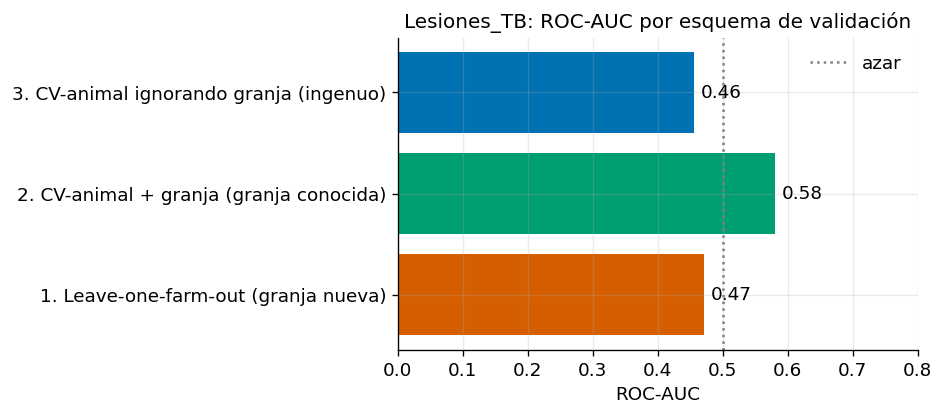

In [8]:
# Reúne los resultados de los tres esquemas para Lesiones_TB (ROC-AUC)
# Esquema 1 (LOFO) y 2 (+granja) se recomputan brevemente aquí para una tabla autocontenida.
from sklearn.model_selection import LeaveOneGroupOut
d=tb.target_subset(df,"Lesiones_TB"); y=d["Lesiones_TB"].astype(int).values; g=d["Expl"].values
def roc_cv(features, cats, est, splitter, grouped=False):
    rocs=[]
    sp = splitter.split(d[features],y,g) if grouped else splitter.split(d[features],y)
    for tr,te in sp:
        if len(np.unique(y[te]))<2: continue
        pipe=Pipeline([("p",tb.make_preprocessor(numeric=[f for f in NUM if f in features],categorical=cats)),("c",est)])
        pipe.fit(d[features].iloc[tr],y[tr]); p=pipe.predict_proba(d[features].iloc[te])[:,1]
        rocs.append(roc_auc_score(y[te],p))
    return np.mean(rocs)
roc_lofo = roc_cv(FEAT, ["RAZA2"], logit(), LeaveOneGroupOut(), grouped=True)
roc_farm = roc_cv(FEAT+["Expl"], ["RAZA2","Expl"], logit(), RepeatedStratifiedKFold(n_splits=5,n_repeats=10,random_state=tb.SEED))
roc_naive= roc_cv(FEAT, ["RAZA2"], logit(), RepeatedStratifiedKFold(n_splits=5,n_repeats=10,random_state=tb.SEED))
comp=pd.DataFrame([
    dict(Esquema="1. Leave-one-farm-out (granja nueva)", ROC_AUC=round(roc_lofo,3), Pregunta="¿generaliza a granja nueva?"),
    dict(Esquema="2. CV-animal + granja (granja conocida)", ROC_AUC=round(roc_farm,3), Pregunta="¿predice animal de granja conocida?"),
    dict(Esquema="3. CV-animal ignorando granja (ingenuo)", ROC_AUC=round(roc_naive,3), Pregunta="pooling por defecto"),
])
print("Lesiones_TB — ROC-AUC bajo los tres esquemas (regresión logística, solo biomarcadores salvo esq.2):")
print(comp.to_string(index=False))
fig,ax=plt.subplots(figsize=(8,3.6))
ax.barh(comp.Esquema, comp.ROC_AUC, color=[PALETTE[1],PALETTE[2],PALETTE[0]])
ax.axvline(0.5, ls=":", color="grey", label="azar"); ax.set_xlim(0,0.8)
for i,v in enumerate(comp.ROC_AUC): ax.text(v+0.01,i,f"{v:.2f}",va="center")
ax.set_xlabel("ROC-AUC"); ax.set_title("Lesiones_TB: ROC-AUC por esquema de validación"); ax.legend()
plt.tight_layout(); plt.savefig("figures/figC4_three_schemes.png"); plt.show()

## 7. Conclusiones del esquema ingenuo

- Ignorando la granja y con solo biomarcadores, el rendimiento es **≈ azar** para lesión y
  patrón, y la correlación fuera de muestra es **casi nula** para IDTC y gravedad.
- Como este esquema es **propenso al optimismo** (comparte granjas entre *train* y *test*) y
  **aun así** no halla señal, el resultado negativo sobre los biomarcadores es **robusto**.
- A la vez, ignorar la granja **oculta** la estructura que sí es informativa (riesgo basal de
  granja) y produce estimaciones asociacionales **no robustas** (E-value del IC = 1,00).
- **Recomendación:** este enfoque no debe usarse como base para decisiones; el *leave-one-farm-out*
  ofrece la estimación honesta de generalización, y el esquema con granja como covariable revela
  dónde está realmente la señal.
